# Unveiling the Android App Market
## Comprehensive Google Play Store Data Analysis

### Objective

This project performs a comprehensive analysis of the Google Play Store ecosystem. The analysis focuses on cleaning messy real-world data, exploring app categories, analysing ratings, investigating the relationship between app size and installations, examining pricing and potential revenue patterns, and conducting sentiment analysis on user reviews.

The project aims to generate meaningful and actionable insights that can help a developer understand the competitive landscape of the Android app market before launching a new application.

### Tools and Technologies

- Python
- pandas
- numpy
- matplotlib
- seaborn
- TextBlob
- Plotly
- Jupyter Notebook

In [1]:
!pip install textblob plotly

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

import plotly.express as px

import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)

print("All required libraries imported successfully!")

All required libraries imported successfully!


# 1. Data Loading and Initial Inspection

Two datasets are loaded separately:

1. **Google Play Store Apps Dataset** – Contains information about Android applications, including categories, ratings, installations, prices and application sizes.

2. **Google Play Store User Reviews Dataset** – Contains user reviews and associated sentiment-related information.

The datasets are initially inspected before cleaning to understand their structure and identify potential data-quality issues.

In [3]:
apps_df = pd.read_csv("googleplaystore.csv")

reviews_df = pd.read_csv(
    "googleplaystore_user_reviews.csv"
)

print("Apps Dataset Shape:")
print(apps_df.shape)

print("\nReviews Dataset Shape:")
print(reviews_df.shape)

Apps Dataset Shape:
(10841, 13)

Reviews Dataset Shape:
(64295, 5)


In [4]:
# Inspect Apps Dataset
print("FIRST FIVE ROWS OF THE APPS DATASET")

display(
    apps_df.head()
)

print("\nCOLUMN NAMES")

print(
    apps_df.columns.tolist()
)

print("\nDATASET INFORMATION")

apps_df.info()

FIRST FIVE ROWS OF THE APPS DATASET


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



COLUMN NAMES
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage

In [5]:
# Inspect Reviews Dataset

print("FIRST FIVE ROWS OF THE REVIEWS DATASET")

display(
    reviews_df.head()
)

print("\nCOLUMN NAMES")

print(
    reviews_df.columns.tolist()
)

print("\nDATASET INFORMATION")

reviews_df.info()

FIRST FIVE ROWS OF THE REVIEWS DATASET


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000



COLUMN NAMES
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 8.3 MB


# 2. Data Quality Assessment

Before performing any cleaning, a data quality assessment is conducted.

The assessment examines:

- Dataset dimensions
- Data types
- Missing values
- Missing-value percentages
- Number of unique values
- Duplicate rows

This initial assessment establishes a baseline for measuring the impact of the subsequent data-cleaning process.

In [6]:
# Apps Data Quality Report

apps_quality_report = pd.DataFrame({
    
    "Data_Type":
        apps_df.dtypes.astype(str),
    
    "Missing_Values":
        apps_df.isnull().sum(),
    
    "Missing_Percentage":
        (
            apps_df.isnull().sum()
            / len(apps_df)
            * 100
        ).round(2),
    
    "Unique_Values":
        apps_df.nunique()
})

display(apps_quality_report)

print("Total Rows:", apps_df.shape[0])

print("Total Columns:", apps_df.shape[1])

print(
    "Duplicate Rows:",
    apps_df.duplicated().sum()
)

,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
App,str,0,0.00,9660
Category,str,0,0.00,34
Rating,float64,1474,13.60,40
Reviews,str,0,0.00,6002
Size,str,0,0.00,462
Installs,str,0,0.00,22
Type,str,1,0.01,3
Price,str,0,0.00,93
Content Rating,str,1,0.01,6
Genres,str,0,0.00,120


Total Rows: 10841
Total Columns: 13
Duplicate Rows: 483


In [7]:
# Reviews Data Quality Report
reviews_quality_report = pd.DataFrame({
    
    "Data_Type":
        reviews_df.dtypes.astype(str),
    
    "Missing_Values":
        reviews_df.isnull().sum(),
    
    "Missing_Percentage":
        (
            reviews_df.isnull().sum()
            / len(reviews_df)
            * 100
        ).round(2),
    
    "Unique_Values":
        reviews_df.nunique()
})

display(reviews_quality_report)

print("Total Rows:", reviews_df.shape[0])

print("Total Columns:", reviews_df.shape[1])

print(
    "Duplicate Rows:",
    reviews_df.duplicated().sum()
)

,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
App,str,0,0.00,1074
Translated_Review,str,26868,41.79,27994
Sentiment,str,26863,41.78,3
Sentiment_Polarity,float64,26863,41.78,5410
Sentiment_Subjectivity,float64,26863,41.78,4474


Total Rows: 64295
Total Columns: 5
Duplicate Rows: 33616


In [8]:
# CREATE BACKUPS

apps_original = apps_df.copy()

reviews_original = reviews_df.copy()

print(
    "Original datasets successfully preserved."
)

Original datasets successfully preserved.


# 3. Data Cleaning

The Google Play Store dataset contains several common real-world data quality issues.

These include:

- Numerical values stored as text
- Installation values containing commas and plus symbols
- Prices containing currency symbols
- Application sizes represented using different units
- Missing values
- Duplicate application records
- Date information stored as text

Each cleaning decision is documented to ensure that the analytical process is transparent and reproducible.

In [9]:
# Record Dataset Size Before Cleaning

apps_rows_before = apps_df.shape[0]

reviews_rows_before = reviews_df.shape[0]

apps_duplicates_before = apps_df.duplicated().sum()

reviews_duplicates_before = reviews_df.duplicated().sum()

print("Apps Rows Before Cleaning:", apps_rows_before)

print("Reviews Rows Before Cleaning:", reviews_rows_before)

Apps Rows Before Cleaning: 10841
Reviews Rows Before Cleaning: 64295


### Cleaning the Installs Column


In [10]:
apps_df["Installs"] = (
    apps_df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .str.strip()
)

apps_df["Installs"] = pd.to_numeric(
    apps_df["Installs"],
    errors="coerce"
)

print(
    apps_df["Installs"]
    .head()
)

print(
    "\nData Type:",
    apps_df["Installs"].dtype
)

0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64

Data Type: float64


### Cleaning the Reviews Column

The `Reviews` variable represents the number of user reviews. It is converted into a numerical data type to ensure that it can be used for duplicate selection and quantitative analysis.

In [11]:
apps_df["Reviews"] = pd.to_numeric(
    apps_df["Reviews"],
    errors="coerce"
)

### Cleaning the Price Column

The `Price` column contains monetary values stored as text, including currency symbols.

The dollar symbol is removed before converting the column into a numerical format.

In [12]:
apps_df["Price"] = (
    apps_df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.strip()
)

apps_df["Price"] = pd.to_numeric(
    apps_df["Price"],
    errors="coerce"
)

print(
    apps_df[
        ["Type", "Price"]
    ].head()
)

   Type  Price
0  Free    0.0
1  Free    0.0
2  Free    0.0
3  Free    0.0
4  Free    0.0


### Standardising Application Size

In [13]:
def convert_size_to_mb(size):
    
    if pd.isna(size):
        return np.nan
    
    size = str(size).strip()
    
    if size == "Varies with device":
        return np.nan
    
    try:
        
        if size.endswith("M"):
            
            return float(
                size[:-1]
            )
        
        elif size.endswith("k"):
            
            return (
                float(
                    size[:-1]
                )
                / 1024
            )
        
        else:
            
            return np.nan
    
    except ValueError:
        
        return np.nan


apps_df["Size_MB"] = (
    apps_df["Size"]
    .apply(convert_size_to_mb)
)

display(
    apps_df[
        ["Size", "Size_MB"]
    ]
    .head(10)
)

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


### Converting Last Updated into Datetime Format

The `Last Updated` column represents temporal information and should therefore use a datetime data type.

Converting the column to datetime format improves consistency and allows future time-based analysis.

In [14]:
apps_df["Last Updated"] = pd.to_datetime(
    apps_df["Last Updated"],
    errors="coerce"
)

print(
    apps_df["Last Updated"]
    .dtype
)

datetime64[us]


### Duplicate Removal Strategy

Two types of duplicates are investigated:

1. Exact duplicate rows.
2. Multiple records representing the same application.

Exact duplicate rows are removed first.

Where multiple records exist for the same application, one record is retained. The record with the highest number of reviews is selected because it provides the largest amount of available user engagement information.

This prevents individual applications from disproportionately influencing the category and rating analyses.

In [15]:
# Remove Exact Duplicates

print(
    "Exact Duplicate Rows Before Removal:",
    apps_df.duplicated().sum()
)

apps_df = (
    apps_df
    .drop_duplicates()
    .copy()
)

print(
    "Exact Duplicate Rows After Removal:",
    apps_df.duplicated().sum()
)

Exact Duplicate Rows Before Removal: 483
Exact Duplicate Rows After Removal: 0


In [16]:
# Remove Duplicate App Names

print(
    "Duplicate Application Names:",
    apps_df["App"].duplicated().sum()
)

apps_df = (
    apps_df
    .sort_values(
        by="Reviews",
        ascending=False
    )
    .drop_duplicates(
        subset="App",
        keep="first"
    )
    .copy()
)

print(
    "Duplicate App Names After Cleaning:",
    apps_df["App"].duplicated().sum()
)

Duplicate Application Names: 698
Duplicate App Names After Cleaning: 0


### Missing Value Handling Strategy


In [17]:
# Apply Missing Value Strategy

apps_df = (
    apps_df
    .dropna(
        subset=[
            "App",
            "Category",
            "Rating",
            "Installs",
            "Type",
            "Price"
        ]
    )
    .copy()
)

print(
    "Remaining Missing Values:"
)

display(
    apps_df
    .isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

Remaining Missing Values:


Size_MB           1170
Current Ver          4
Android Ver          2
App                  0
Category             0
Rating               0
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
dtype: int64

### Cleaning the User Reviews Dataset

In [18]:
print(
    "Duplicate Rows Before Removal:",
    reviews_df.duplicated().sum()
)

reviews_df = (
    reviews_df
    .drop_duplicates()
    .copy()
)

reviews_clean = (
    reviews_df
    .dropna(
        subset=[
            "App",
            "Translated_Review"
        ]
    )
    .copy()
)

print(
    "Reviews Dataset Shape After Cleaning:",
    reviews_clean.shape
)

Duplicate Rows Before Removal: 33616
Reviews Dataset Shape After Cleaning: (29692, 5)


# 4. Before and After Cleaning Summary

In [19]:
cleaning_summary = pd.DataFrame({

    "Metric": [
        "Number of Rows",
        "Total Missing Values",
        "Duplicate Rows"
    ],

    "Apps Before": [
        apps_original.shape[0],
        apps_original.isnull().sum().sum(),
        apps_original.duplicated().sum()
    ],

    "Apps After": [
        apps_df.shape[0],
        apps_df.isnull().sum().sum(),
        apps_df.duplicated().sum()
    ],

    "Reviews Before": [
        reviews_original.shape[0],
        reviews_original.isnull().sum().sum(),
        reviews_original.duplicated().sum()
    ],

    "Reviews After": [
        reviews_clean.shape[0],
        reviews_clean.isnull().sum().sum(),
        reviews_clean.duplicated().sum()
    ]
})

display(cleaning_summary)

,Metric,Apps Before,Apps After,Reviews Before,Reviews After
0,Number of Rows,10841,8196,64295,29692
1,Total Missing Values,1487,1176,107457,0
2,Duplicate Rows,483,0,33616,0


# 5. Category Analysis

This section investigates the distribution of applications across Google Play Store categories.

Categories containing large numbers of applications can be considered more saturated markets. High saturation may indicate stronger competition for developers entering those areas.

In [20]:
# category counts

category_counts = (
    apps_df["Category"]
    .value_counts()
    .sort_values(
        ascending=False
    )
)

display(
    category_counts
)

Category
FAMILY                 1653
GAME                    898
TOOLS                   720
FINANCE                 302
PRODUCTIVITY            301
LIFESTYLE               301
PERSONALIZATION         298
MEDICAL                 290
PHOTOGRAPHY             263
BUSINESS                263
SPORTS                  260
COMMUNICATION           256
HEALTH_AND_FITNESS      244
NEWS_AND_MAGAZINES      204
SOCIAL                  203
TRAVEL_AND_LOCAL        187
SHOPPING                180
BOOKS_AND_REFERENCE     169
VIDEO_PLAYERS           149
DATING                  133
MAPS_AND_NAVIGATION     118
EDUCATION               104
FOOD_AND_DRINK           94
ENTERTAINMENT            86
AUTO_AND_VEHICLES        73
WEATHER                  72
LIBRARIES_AND_DEMO       64
HOUSE_AND_HOME           61
ART_AND_DESIGN           59
COMICS                   54
PARENTING                50
EVENTS                   45
BEAUTY                   42
Name: count, dtype: int64

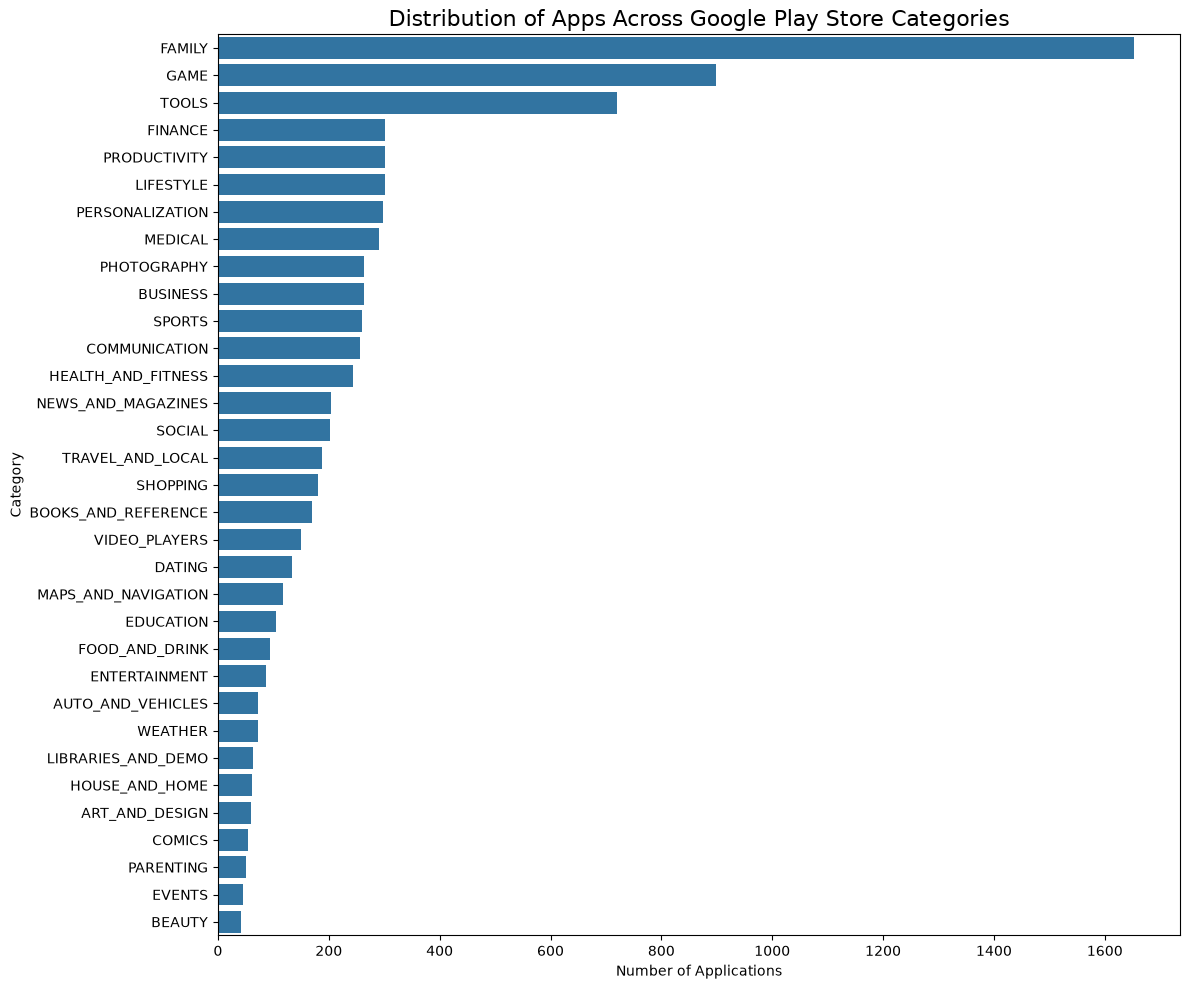

In [21]:
# Category Distribution Chart

plt.figure(
    figsize=(12, 10)
)

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title(
    "Distribution of Apps Across Google Play Store Categories",
    fontsize=16
)

plt.xlabel("Number of Applications")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [22]:
# Identify Most Saturated Categories

top_saturated_categories = (
    category_counts
    .head(10)
)

print(
    "Top 10 Most Saturated Categories:"
)

display(
    top_saturated_categories
)

Top 10 Most Saturated Categories:


Category
FAMILY             1653
GAME                898
TOOLS               720
FINANCE             302
PRODUCTIVITY        301
LIFESTYLE           301
PERSONALIZATION     298
MEDICAL             290
PHOTOGRAPHY         263
BUSINESS            263
Name: count, dtype: int64

### Observation

The category distribution shows that some areas of the Google Play Store contain substantially more applications than others. Categories with the highest number of applications can be considered the most saturated and may involve greater competition for new developers.

# 6. Ratings Analysis

App ratings provide an indication of user satisfaction.

This section examines:

1. The overall distribution of application ratings.
2. The average rating for each application category.

These analyses help identify general patterns of customer satisfaction across the Google Play Store ecosystem.

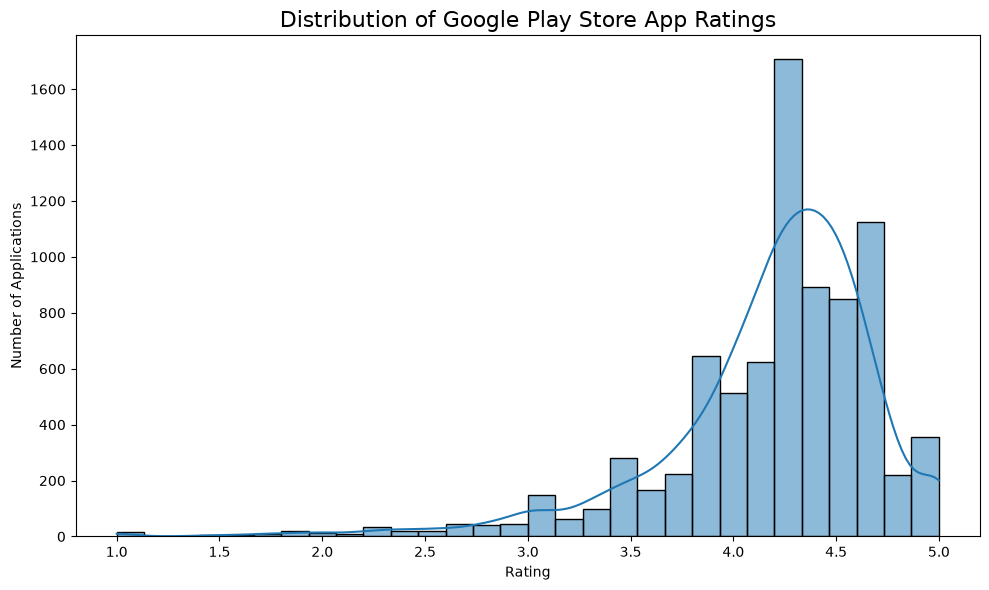

In [23]:
plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    data=apps_df,
    x="Rating",
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Google Play Store App Ratings",
    fontsize=16
)

plt.xlabel("Rating")

plt.ylabel("Number of Applications")

plt.tight_layout()

plt.show()

### Observation

The distribution illustrates the overall pattern of user ratings across the applications included in the cleaned dataset.

The concentration of ratings around particular values provides an indication of general user satisfaction. Extremely high or low ratings should be interpreted alongside the number of reviews because an application with very few reviews may have a less reliable rating.

In [24]:
average_rating_by_category = (
    apps_df
    .groupby("Category")["Rating"]
    .mean()
    .sort_values(
        ascending=False
    )
)

display(
    average_rating_by_category
)

Category
EVENTS                 4.435556
ART_AND_DESIGN         4.359322
EDUCATION              4.349038
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
SOCIAL                 4.247291
GAME                   4.244432
WEATHER                4.243056
HEALTH_AND_FITNESS     4.243033
SHOPPING               4.230556
SPORTS                 4.216154
AUTO_AND_VEHICLES      4.190411
FAMILY                 4.184150
PRODUCTIVITY           4.183389
COMICS                 4.181481
LIBRARIES_AND_DEMO     4.178125
FOOD_AND_DRINK         4.171277
MEDICAL                4.165862
PHOTOGRAPHY            4.155894
HOUSE_AND_HOME         4.140984
ENTERTAINMENT          4.129070
NEWS_AND_MAGAZINES     4.121569
COMMUNICATION          4.121484
FINANCE                4.115563
BUSINESS               4.098479
LIFESTYLE              4.093355
TRAVEL_AND_LOCAL       4.069519
VIDEO_PLAYERS          4.044966
TOOLS                  4.040278

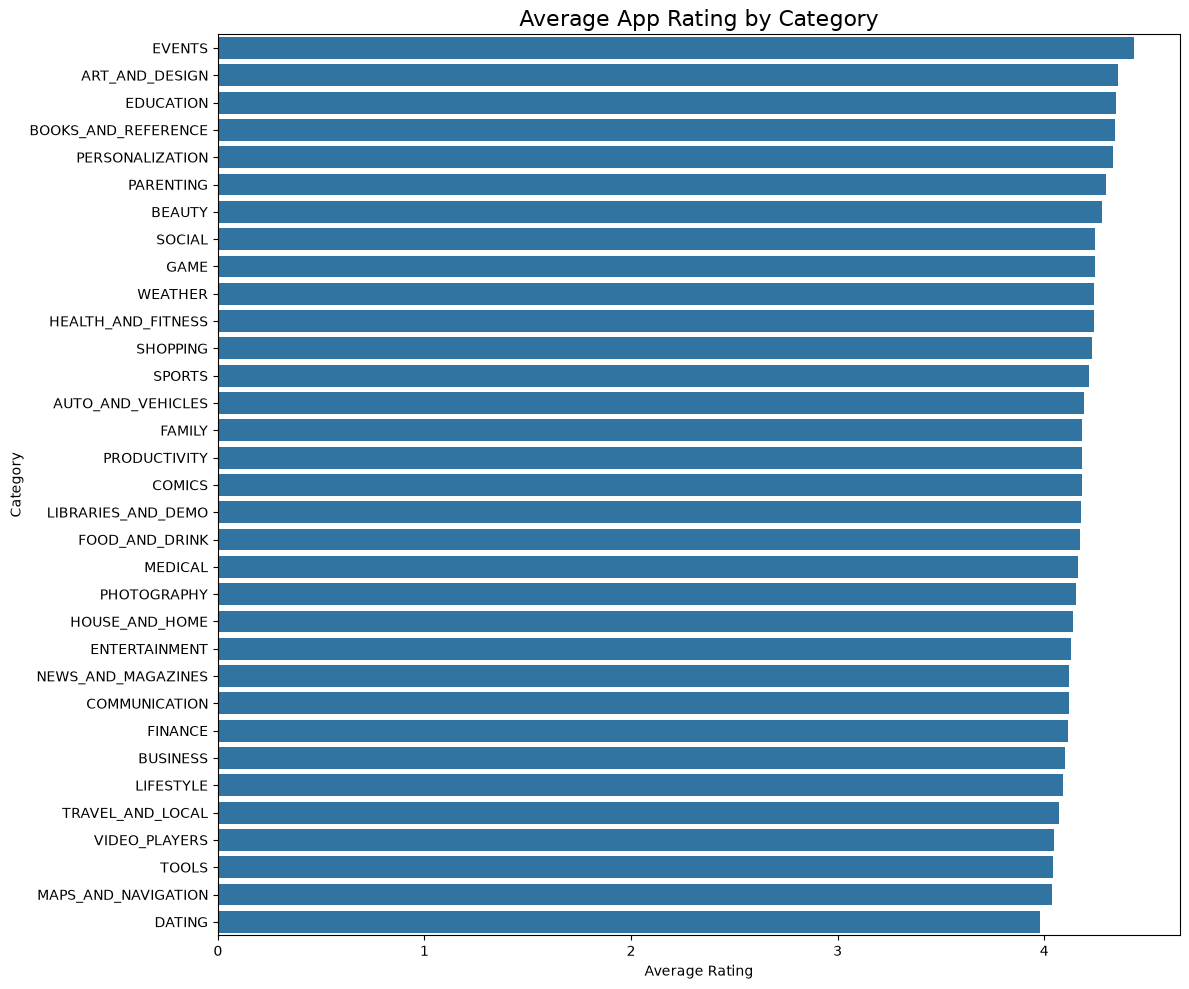

In [25]:
plt.figure(
    figsize=(12, 10)
)

sns.barplot(
    x=average_rating_by_category.values,
    y=average_rating_by_category.index
)

plt.title(
    "Average App Rating by Category",
    fontsize=16
)

plt.xlabel("Average Rating")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

### Observation

The comparison of average ratings reveals differences in user satisfaction between application categories.

Categories with high average ratings may indicate successful alignment with user expectations. However, categories containing relatively few applications should be interpreted cautiously because small sample sizes may produce unusually high or low average ratings.

# 7. Application Size and Installation Analysis

This section investigates whether the size of an application is related to its number of installations.

A scatter plot is used to visualise the relationship, while Pearson correlation is calculated to measure the strength and direction of the linear association.

It is important to note that correlation does not demonstrate causation.

In [26]:
# Create Analysis Dataset

size_installs_df = (
    apps_df
    .dropna(
        subset=[
            "Size_MB",
            "Installs"
        ]
    )
    .copy()
)

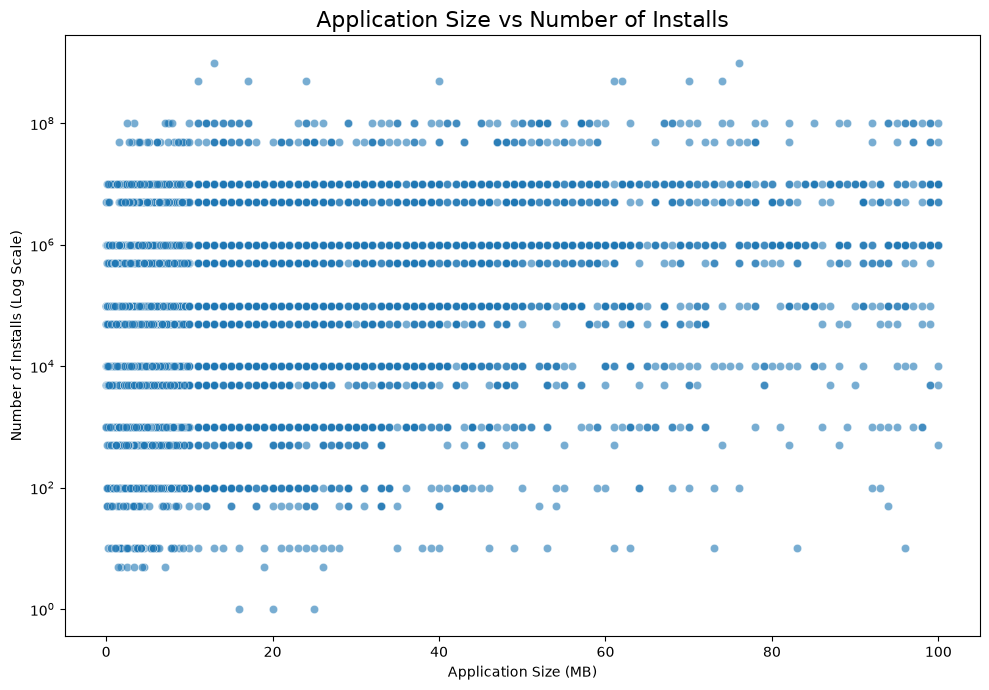

In [27]:
# Scatter Plot
plt.figure(
    figsize=(10, 7)
)

sns.scatterplot(
    data=size_installs_df,
    x="Size_MB",
    y="Installs",
    alpha=0.6
)

plt.yscale("log")

plt.title(
    "Application Size vs Number of Installs",
    fontsize=16
)

plt.xlabel("Application Size (MB)")

plt.ylabel("Number of Installs (Log Scale)")

plt.tight_layout()

plt.show()

### Observation

The scatter plot illustrates the relationship between application size and installation numbers. The Pearson correlation value calculated above provides a numerical measure of the linear relationship between these variables.

The result should be interpreted carefully because application installations can also be influenced by factors such as application quality, marketing, brand reputation and functionality.

In [28]:
# Correlation

size_install_correlation = (
    size_installs_df["Size_MB"]
    .corr(
        size_installs_df["Installs"]
    )
)

print(
    "Pearson Correlation Between App Size and Installs:"
)

print(
    round(
        size_install_correlation,
        4
    )
)

Pearson Correlation Between App Size and Installs:
0.1317


# 8. Pricing Analysis

This section investigates:

- The distribution of free and paid applications.
- The price distribution of paid applications.
- The theoretical gross revenue generated by different categories.


In [29]:
# Free vs Paid Distribution
app_type_counts = (
    apps_df["Type"]
    .value_counts()
)

display(
    app_type_counts
)

Type
Free    7594
Paid     602
Name: count, dtype: int64

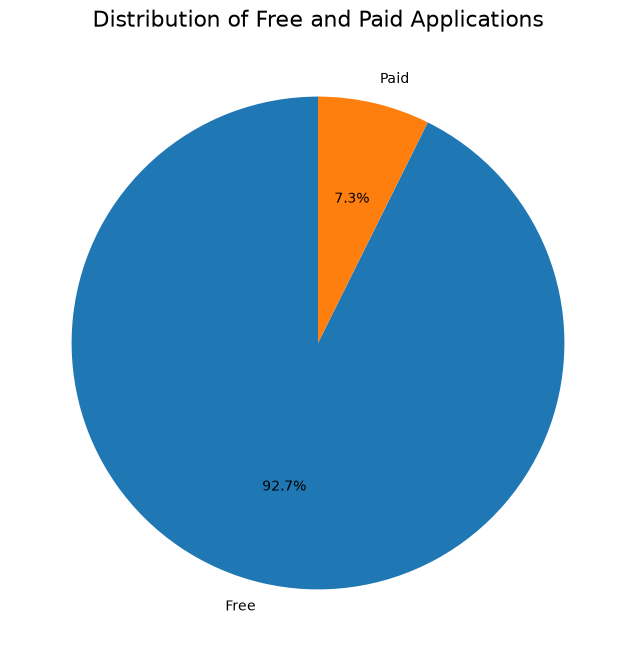

In [30]:
# Free vs Paid Chart
plt.figure(
    figsize=(8, 8)
)

plt.pie(
    app_type_counts.values,
    labels=app_type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Distribution of Free and Paid Applications",
    fontsize=16
)

plt.show()

In [31]:
# Paid App Price Distribution
paid_apps = (
    apps_df[
        apps_df["Type"] == "Paid"
    ]
    .copy()
)

print(
    "Number of Paid Applications:",
    len(paid_apps)
)

Number of Paid Applications: 602


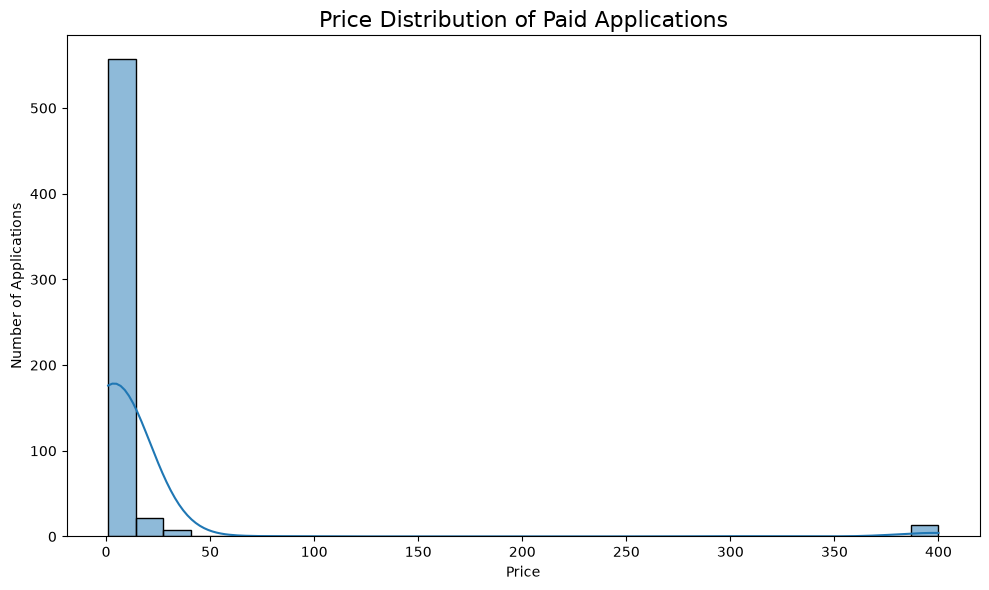

In [32]:
plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    data=paid_apps,
    x="Price",
    bins=30,
    kde=True
)

plt.title(
    "Price Distribution of Paid Applications",
    fontsize=16
)

plt.xlabel("Price")

plt.ylabel("Number of Applications")

plt.tight_layout()

plt.show()

### Observation

The price distribution shows the range and concentration of prices among paid applications. A concentration around lower prices may indicate that developers use affordable pricing to reduce barriers for potential customers.

In [33]:
# THEORETICAL REVENUE ESTIMATION

apps_df["Theoretical_Gross_Revenue"] = (
    apps_df["Price"]
    * apps_df["Installs"]
)

In [34]:
# Revenue by Category

revenue_by_category = (
    apps_df
    .groupby("Category")[
        "Theoretical_Gross_Revenue"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
)

display(
    revenue_by_category
)

Category
FAMILY                 1.156748e+08
LIFESTYLE              5.758394e+07
GAME                   4.068784e+07
FINANCE                2.572664e+07
PHOTOGRAPHY            8.546050e+06
PERSONALIZATION        6.796310e+06
MEDICAL                5.871056e+06
TOOLS                  5.462910e+06
SPORTS                 4.706154e+06
PRODUCTIVITY           4.304452e+06
COMMUNICATION          4.247100e+06
WEATHER                4.179885e+06
HEALTH_AND_FITNESS     1.420270e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.149250e+06
BUSINESS               1.047648e+06
ENTERTAINMENT          7.980000e+05
EDUCATION              4.029900e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      9.950000e+04
BOOKS_AND_REFERENCE    8.890150e+04
DATING                 4.069900e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6.445000e+03
SOCIAL             

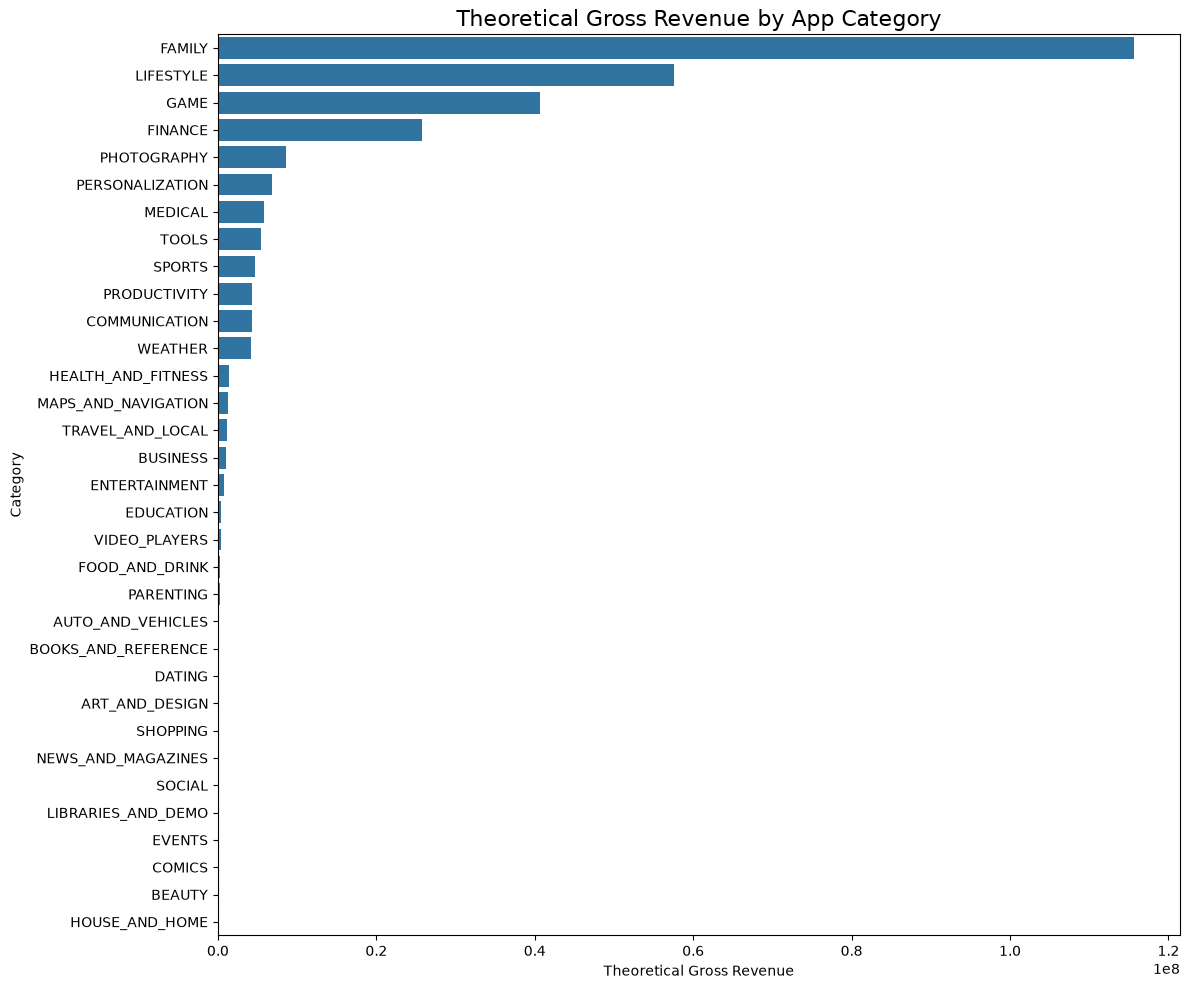

In [35]:
# Revenue Chart

plt.figure(
    figsize=(12, 10)
)

sns.barplot(
    x=revenue_by_category.values,
    y=revenue_by_category.index
)

plt.title(
    "Theoretical Gross Revenue by App Category",
    fontsize=16
)

plt.xlabel("Theoretical Gross Revenue")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

### Observation

The categories with the highest theoretical gross revenue combine application price and installation volume.

However, these values should be considered estimates rather than actual revenue because the calculation does not account for refunds, discounts, platform commissions or alternative monetisation strategies.

# 9. User Review Sentiment Analysis


In [36]:
# Sentiment Classification Function

def classify_sentiment(review):
    
    if pd.isna(review):
        return np.nan
    
    polarity = (
        TextBlob(
            str(review)
        )
        .sentiment
        .polarity
    )
    
    if polarity > 0.1:
        
        return "Positive"
    
    elif polarity < -0.1:
        
        return "Negative"
    
    else:
        
        return "Neutral"

In [37]:
# Apply TextBlob Sentiment Analysis

reviews_clean["TextBlob_Sentiment"] = (
    reviews_clean["Translated_Review"]
    .apply(classify_sentiment)
)

sentiment_counts = (
    reviews_clean["TextBlob_Sentiment"]
    .value_counts()
)

display(
    sentiment_counts
)

TextBlob_Sentiment
Positive    16464
Neutral      8832
Negative     4396
Name: count, dtype: int64

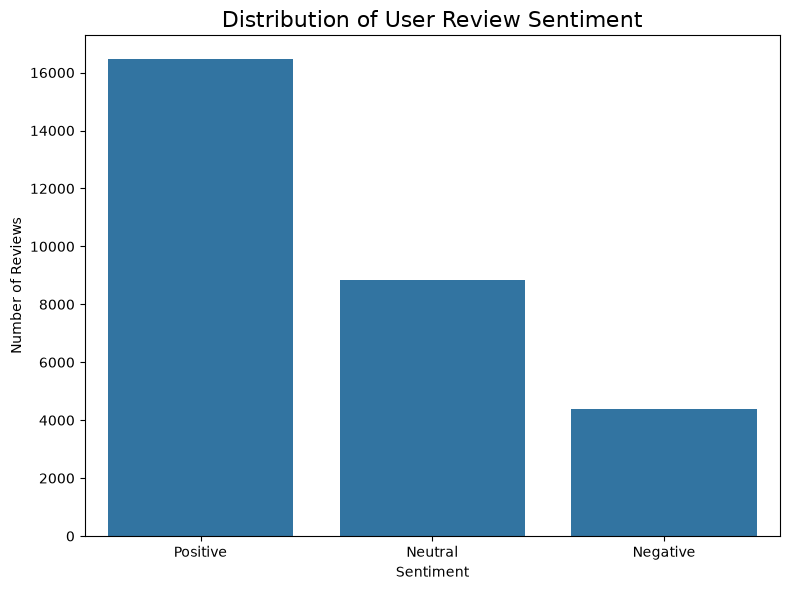

In [38]:
# Sentiment Distribution Chart

plt.figure(
    figsize=(8, 6)
)

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title(
    "Distribution of User Review Sentiment",
    fontsize=16
)

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

In [39]:
print("FINAL DATA TYPES - APPS DATASET")
print(apps_df.dtypes)

print("\nFINAL DATA TYPES - REVIEWS DATASET")
print(reviews_clean.dtypes)

FINAL DATA TYPES - APPS DATASET
App                                     str
Category                                str
Rating                              float64
Reviews                             float64
Size                                    str
Installs                            float64
Type                                    str
Price                               float64
Content Rating                          str
Genres                                  str
Last Updated                 datetime64[us]
Current Ver                             str
Android Ver                             str
Size_MB                             float64
Theoretical_Gross_Revenue           float64
dtype: object

FINAL DATA TYPES - REVIEWS DATASET
App                           str
Translated_Review             str
Sentiment                     str
Sentiment_Polarity        float64
Sentiment_Subjectivity    float64
TextBlob_Sentiment            str
dtype: object


# 10. Sentiment Analysis by Application Category

The user reviews dataset does not directly contain application category information.

Therefore, the application name is used as a common variable to merge category information from the cleaned Google Play Store applications dataset.

The analysis then calculates the percentage of positive, negative and neutral reviews for each category.

In [40]:
app_category_mapping = (
    apps_df[
        [
            "App",
            "Category"
        ]
    ]
    .drop_duplicates(
        subset="App"
    )
)

In [41]:
# Merge Reviews With Categories

reviews_with_category = (
    reviews_clean
    .merge(
        app_category_mapping,
        on="App",
        how="inner"
    )
)

print(
    "Merged Dataset Shape:"
)

print(
    reviews_with_category.shape
)

Merged Dataset Shape:
(28250, 7)


In [42]:
# Sentiment Percentages by Category

sentiment_by_category = (
    pd.crosstab(
        reviews_with_category["Category"],
        reviews_with_category[
            "TextBlob_Sentiment"
        ],
        normalize="index"
    )
    * 100
)

display(
    sentiment_by_category
    .round(2)
)

TextBlob_Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,10.48,27.54,61.98
AUTO_AND_VEHICLES,4.59,19.79,75.62
BEAUTY,17.35,29.02,53.63
BOOKS_AND_REFERENCE,10.21,27.07,62.72
BUSINESS,13.85,33.79,52.36
COMICS,0.00,15.56,84.44
COMMUNICATION,13.80,33.68,52.51
DATING,15.64,28.33,56.03
EDUCATION,7.71,23.12,69.17


In [43]:
# Categories With Most Positive Sentiment

highest_positive_categories = (
    sentiment_by_category["Positive"]
    .sort_values(
        ascending=False
    )
)

print(
    "Categories With Highest Positive Sentiment:"
)

display(
    highest_positive_categories.head(10)
)

Categories With Highest Positive Sentiment:


Category
COMICS                84.444444
EVENTS                75.641026
AUTO_AND_VEHICLES     75.618375
HEALTH_AND_FITNESS    71.437384
EDUCATION             69.171484
PARENTING             67.578125
FOOD_AND_DRINK        66.723842
WEATHER               64.948454
PERSONALIZATION       64.620187
LIBRARIES_AND_DEMO    63.855422
Name: Positive, dtype: float64

In [44]:
# Categories With Most Negative Sentiment

highest_negative_categories = (
    sentiment_by_category["Negative"]
    .sort_values(
        ascending=False
    )
)

print(
    "Categories With Highest Negative Sentiment:"
)

display(
    highest_negative_categories.head(10)
)

Categories With Highest Negative Sentiment:


Category
GAME                22.086202
VIDEO_PLAYERS       21.472393
SOCIAL              21.180030
FAMILY              19.751603
ENTERTAINMENT       18.116976
BEAUTY              17.350158
SPORTS              16.365132
DATING              15.639374
FINANCE             15.494012
TRAVEL_AND_LOCAL    15.401953
Name: Negative, dtype: float64

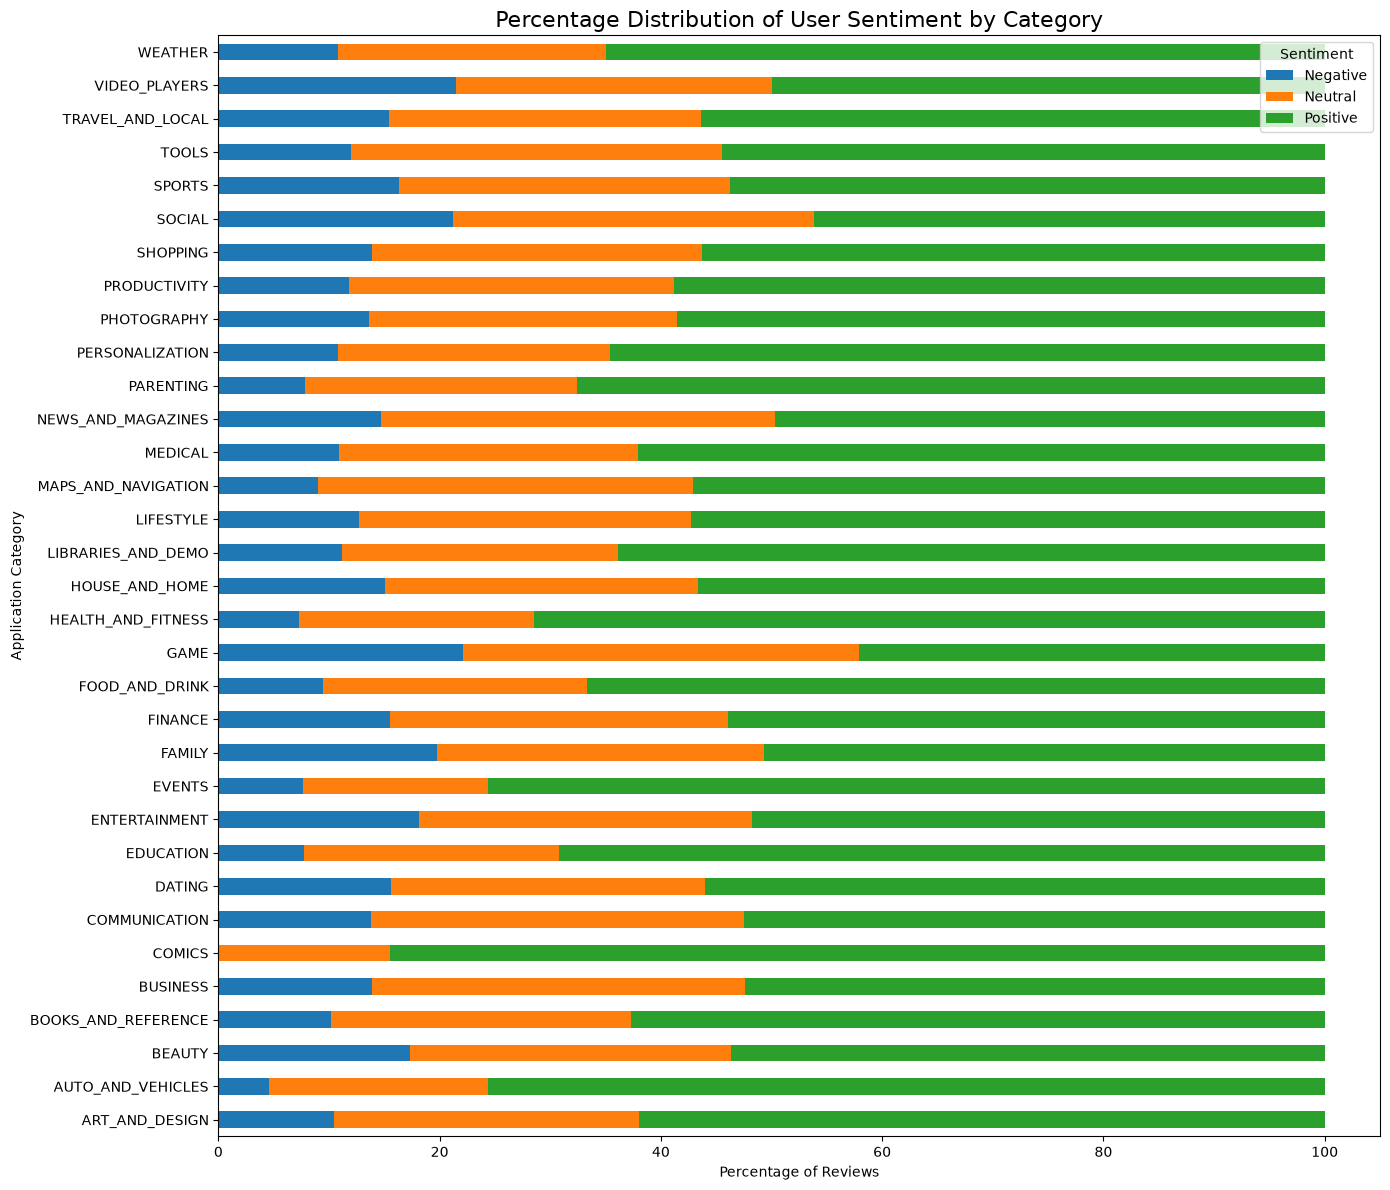

In [45]:
# Stacked Sentiment Chart

sentiment_by_category.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 12)
)

plt.title(
    "Percentage Distribution of User Sentiment by Category",
    fontsize=16
)

plt.xlabel(
    "Percentage of Reviews"
)

plt.ylabel(
    "Application Category"
)

plt.legend(
    title="Sentiment"
)

plt.tight_layout()

plt.show()

### Observation

This analysis identifies categories with relatively high proportions of positive and negative user sentiment.

Categories with high positive sentiment may demonstrate strong alignment with user expectations. Categories with higher negative sentiment may provide opportunities for developers to investigate common user problems and develop improved solutions.

# 11. Interactive Category Analysis

In [46]:
# Create Category Summary

category_summary = (
    apps_df
    .groupby("Category")
    .agg(
        
        Number_of_Apps=(
            "App",
            "count"
        ),
        
        Average_Rating=(
            "Rating",
            "mean"
        ),
        
        Total_Installs=(
            "Installs",
            "sum"
        )
    )
    .reset_index()
)

display(
    category_summary.head()
)

,Category,Number_of_Apps,Average_Rating,Total_Installs
0,ART_AND_DESIGN,59,4.359322,1.132331e+08
1,AUTO_AND_VEHICLES,73,4.190411,5.312980e+07
2,BEAUTY,42,4.278571,2.691620e+07
3,BOOKS_AND_REFERENCE,169,4.344970,1.665792e+09
4,BUSINESS,263,4.098479,6.970181e+08


In [47]:
fig = px.scatter(
    
    category_summary,
    
    x="Number_of_Apps",
    
    y="Average_Rating",
    
    size="Total_Installs",
    
    color="Category",
    
    hover_name="Category",
    
    title=(
        "Google Play Store Categories: "
        "Competition, Ratings and Market Reach"
    ),
    
    log_x=True,
    
    size_max=60
)

fig.update_layout(
    
    xaxis_title="Number of Applications",
    
    yaxis_title="Average Rating"
)

fig.show()

In [48]:
# key findings

print("=" * 70)
print("KEY FINDINGS FROM GOOGLE PLAY STORE ANALYSIS")
print("=" * 70)

print("\n1. FIVE MOST SATURATED CATEGORIES")
print(
    category_counts.head(5)
)

print("\n2. FIVE HIGHEST AVERAGE-RATED CATEGORIES")
print(
    average_rating_by_category.head(5)
)

print("\n3. APP SIZE VS INSTALLS CORRELATION")
print(
    round(
        size_install_correlation,
        4
    )
)

print("\n4. FREE VS PAID APPLICATION DISTRIBUTION")
print(
    app_type_counts
)

print("\n5. FIVE HIGHEST THEORETICAL REVENUE CATEGORIES")
print(
    revenue_by_category.head(5)
)

print("\n6. OVERALL USER SENTIMENT")
print(
    sentiment_counts
)

print("\n7. FIVE CATEGORIES WITH HIGHEST POSITIVE SENTIMENT")
print(
    highest_positive_categories.head(5)
)

print("\n8. FIVE CATEGORIES WITH HIGHEST NEGATIVE SENTIMENT")
print(
    highest_negative_categories.head(5)
)

KEY FINDINGS FROM GOOGLE PLAY STORE ANALYSIS

1. FIVE MOST SATURATED CATEGORIES
Category
FAMILY          1653
GAME             898
TOOLS            720
FINANCE          302
PRODUCTIVITY     301
Name: count, dtype: int64

2. FIVE HIGHEST AVERAGE-RATED CATEGORIES
Category
EVENTS                 4.435556
ART_AND_DESIGN         4.359322
EDUCATION              4.349038
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
Name: Rating, dtype: float64

3. APP SIZE VS INSTALLS CORRELATION
0.1317

4. FREE VS PAID APPLICATION DISTRIBUTION
Type
Free    7594
Paid     602
Name: count, dtype: int64

5. FIVE HIGHEST THEORETICAL REVENUE CATEGORIES
Category
FAMILY         1.156748e+08
LIFESTYLE      5.758394e+07
GAME           4.068784e+07
FINANCE        2.572664e+07
PHOTOGRAPHY    8.546050e+06
Name: Theoretical_Gross_Revenue, dtype: float64

6. OVERALL USER SENTIMENT
TextBlob_Sentiment
Positive    16464
Neutral      8832
Negative     4396
Name: count, dtype: int64

7. FIVE CATEGORIES WITH H

# 12. Final Conclusion and Recommendations

This project analysed the Google Play Store ecosystem using application and user review datasets. The analysis included data cleaning, category analysis, ratings, installations, pricing and sentiment analysis.

## Insight 1: Market Competition

The category analysis showed that some categories contain significantly more applications than others. Highly saturated categories may create greater competition for new developers.

**Recommendation:** Developers should identify specific user needs and create unique features that differentiate their applications from competitors.

## Insight 2: User Satisfaction

Ratings and sentiment analysis demonstrated differences in user satisfaction across application categories. Negative reviews can reveal common problems experienced by users.

**Recommendation:** Developers should analyse negative customer feedback from competing applications and use these insights to improve their products.

## Insight 3: Monetisation Strategy

The pricing analysis showed the importance of free and paid application models in the Google Play Store. Direct pricing may be challenging when users have access to similar free alternatives.

**Recommendation:** Developers should consider alternative monetisation strategies such as subscriptions, advertising, freemium models or in-app purchases.

## Final Recommendation

Overall, developers should not rely on a single factor when launching a new application. A successful strategy should combine market research, competitive analysis, customer feedback and an appropriate monetisation model to identify opportunities and deliver value to users.